# City2Graph brings Overture Maps to network sciences and GNNs

![](https://upload.wikimedia.org/wikipedia/commons/b/bf/Golden_Gate_Bridge_as_seen_from_Battery_East.jpg)

Photo by [Lance Anderson](https://unsplash.com/@lanceanderson) on [Unsplash](https://unsplash.com/)

**If you have ever worked with street networks in Python, chances are you have used [OSMnx](https://osmnx.readthedocs.io/).** Geoff Boeing's library turned what used to be a painful exercise in data wrangling into a one-liner: give it a place name, get back a graph. No manual downloads, no coordinate lookups, no format conversions. Just `ox.graph_from_place("Liverpool, UK")` and you are ready to go.

That simplicity changed the game for urban researchers, transport planners, and spatial data scientists worldwide. OpenStreetMap became the default source for street-level analysis, and OSMnx became the default gateway to it.

But OSM is not without its challenges. As a community-driven project, data quality and completeness vary significantly across regions. Attribute schemas are inconsistent: the same real-world feature can be tagged in dozens of different ways depending on who mapped it and when. For researchers and companies that need reliable, structured data at global scale, these inconsistencies create real friction.

[Overture Maps](https://overturemaps.org/) was founded to address exactly this. Backed by Amazon, Meta, Microsoft, and TomTom, the project takes OSM as one of its core inputs and combines it with commercial and governmental datasets, then applies schema standardisation, validation, and conflation to produce a single, versioned data product. The result is not a replacement for OSM but a layer on top of it: cleaner schemas, richer attributes, and broader thematic coverage. Buildings, streets, POIs, land use, land cover, water bodies, administrative boundaries — all under one interoperable schema.

The problem? **Overture Maps has lacked the same convenient, Pythonic interface that made OSMnx so beloved.** Until now.

This post shows how **city2graph** brings the OSMnx-like experience to Overture Maps data — and then some.

# What is Overture Maps?

[Overture Maps](https://overturemaps.org/) is an open data project that combines, validates, and standardises geospatial datasets from multiple providers. Rather than relying on a single community-driven source (as OSM does), Overture merges contributions from commercial mapping companies, government datasets, and open communities to produce a unified, versioned data product.

The available data types span a wide range of urban and environmental features:

| **Type** | **Description** |
| --- | --- |
| `building` | Building footprints (outer geometry) |
| `segment` | Road, rail, and water paths for travel |
| `connector` | Points connecting segments in the transport network |
| `place` | Points of interest: schools, businesses, hospitals, landmarks |
| `land_use` | Human use classifications (from OSM landuse) |
| `land_cover` | Derived from ESA WorldCover satellite data |
| `infrastructure` | Communication towers, piers, bridges |
| `division` | Administrative and political divisions |
| `water` | Inland and ocean marine surfaces |
| `address` | Physical addresses with structured attributes |

Why does this matter? Because when you are building a heterogeneous graph of a city — connecting buildings to streets, streets to transit stops, POIs to administrative zones — you need all these layers to come from a consistent, well-structured source. Overture provides that foundation.

# What is City2Graph?

If you read the [previous post](https://medium.com/@yuta.sato.now/city2graph-a-python-package-for-spatial-network-analysis-and-graph-neural-networks-gnns-bc943dd6d85e), you already know the story. [**city2graph**](https://city2graph.net/) is a Python package that converts any geospatial dataset into graph representations, with an interchangeable interface across [GeoPandas](https://geopandas.org/), [NetworkX](https://networkx.org/), and [PyTorch Geometric](https://pytorch-geometric.readthedocs.io/).

It handles morphology, transportation, mobility, proximity, and contiguity graphs — all from a unified API. But one question kept coming up from users:

> *"How do I actually get the data in the first place?"*
> 

For OSM street networks, OSMnx solved that problem beautifully. For everything else, researchers were left writing custom download scripts, parsing GeoJSON files, and manually clipping datasets to their study area.

**city2graph's `load_overture_data()` function closes that gap.** It gives you the same one-liner convenience that OSMnx provides for streets, but for the entire Overture Maps catalogue.

# Loading Overture Maps data with `load_overture_data()`

The `load_overture_data()` function is the OSMnx-style gateway to Overture Maps. It supports three ways to define your area of interest: bounding box, polygon, and place name. Let us walk through each — and visualise the results every time, so you can see exactly what you are getting.

First, make sure city2graph is installed:

In [1]:
!pip install city2graph

ERROR: Ignored the following versions that require a different python version: 0.1.0 Requires-Python <4.0,>=3.11; 0.1.1 Requires-Python <4.0,>=3.11; 0.1.2 Requires-Python <4.0,>=3.11; 0.1.3 Requires-Python <4.0,>=3.11; 0.1.4 Requires-Python <4.0,>=3.11; 0.1.5 Requires-Python <4.0,>=3.11; 0.1.6 Requires-Python <4.0,>=3.11; 0.1.7 Requires-Python <3.14,>=3.11; 0.2.0 Requires-Python <3.14,>=3.11; 0.2.1 Requires-Python <3.14,>=3.11; 0.2.2 Requires-Python <3.14,>=3.11; 0.2.3 Requires-Python <3.14,>=3.11; 0.2.4 Requires-Python <3.14,>=3.11
ERROR: Could not find a version that satisfies the requirement city2graph (from versions: none)
ERROR: No matching distribution found for city2graph


Then import the packages:

In [2]:
import city2graph as c2g
import matplotlib.pyplot as plt

/Users/yutasato/Projects/Liverpool/city2graph-workshop/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## By bounding box

If you already know the coordinates of your study area, pass them directly as `[min_lon, min_lat, max_lon, max_lat]`:

In [3]:
# Download buildings and streets for a slice of Manhattan
bbox = [-74.01, 40.70, -73.99, 40.72]

data = c2g.load_overture_data(
    area=bbox,
    types=["building"],
    save_to_file=False
)

# Project all data to a local metric CRS (UTM)
crs = next(iter(data.values())).estimate_utm_crs()
data = {k: v.to_crs(crs) for k, v in data.items()}


buildings = data["building"]

print(f"Buildings: {len(buildings)}")

Buildings: 2847


This is handy for quick prototyping when you have exact coordinates to hand. Let us see what we got:

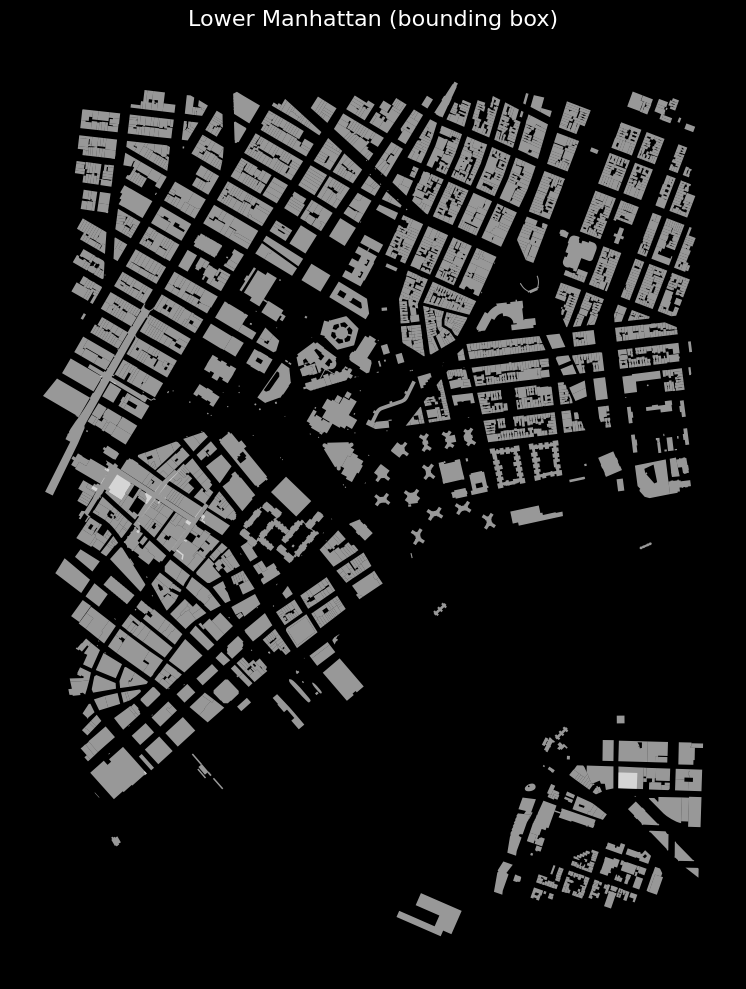

In [4]:
fig, ax = plt.subplots(figsize=(10, 10), facecolor="#000000")
ax.set_facecolor("#000000")
buildings.plot(ax=ax, color="white", alpha=0.6, linewidth=0.1)
ax.set_axis_off()
ax.set_title("Lower Manhattan (bounding box)", color="white", fontsize=16, pad=10)
plt.tight_layout()
plt.show()

Even with raw geometries and no graph processing, the street pattern and building fabric of Lower Manhattan are immediately visible. White footprints packed tight against teal streets — that is the Financial District in a single plot.

## By polygon

For custom study areas — say, a buffered zone around a park or an irregular administrative boundary — you can pass a Shapely `Polygon` directly:

In [5]:
from shapely.geometry import Polygon

# Define a custom polygon (e.g., a rough outline of a neighbourhood)
study_area = Polygon([
    (-2.98, 53.39),
    (-2.98, 53.42),
    (-2.94, 53.42),
    (-2.94, 53.39),
])

data = c2g.load_overture_data(
    area=study_area,
    types=["building", "segment", "connector"],
    save_to_file=False
)

# Project all data to a local metric CRS (UTM)
crs = next(iter(data.values())).estimate_utm_crs()
data = {k: v.to_crs(crs) for k, v in data.items()}


You can also pass a `GeoDataFrame` or `GeoSeries` with CRS information — city2graph will handle reprojection to WGS84 automatically.

A quick plot confirms that the data is clipped neatly to our polygon:

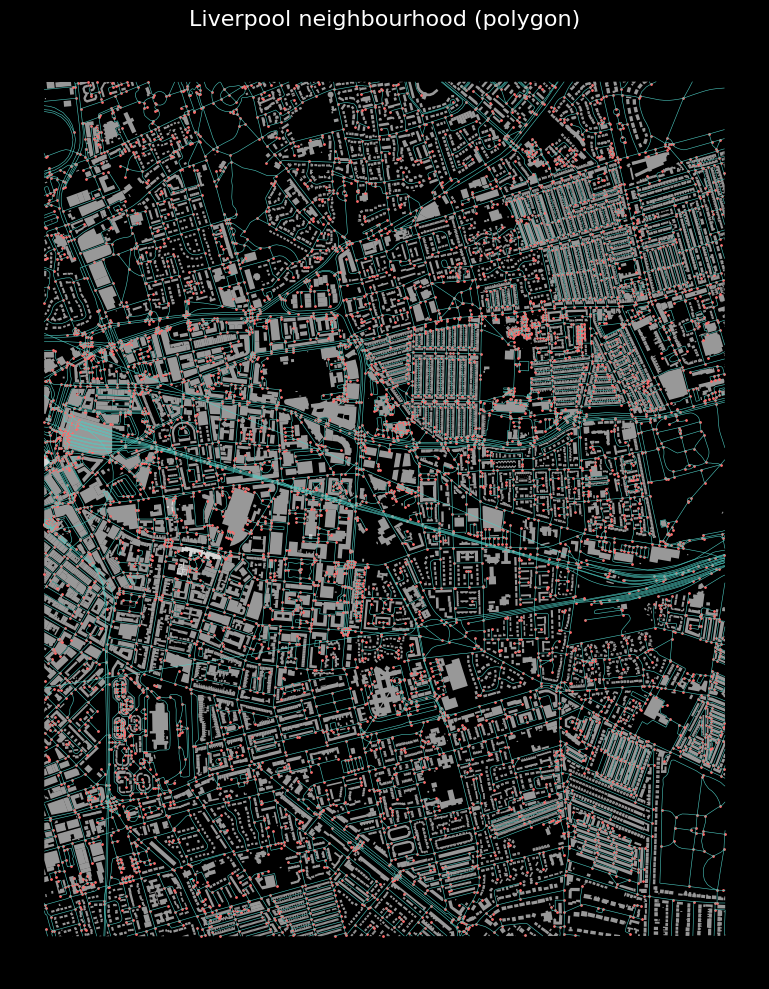

In [6]:
fig, ax = plt.subplots(figsize=(10, 10), facecolor="#000000")
ax.set_facecolor("#000000")
data["building"].plot(ax=ax, color="white", alpha=0.6, linewidth=0.1)
data["segment"].plot(ax=ax, color="#4ECDC4", linewidth=0.4)
data["connector"].plot(ax=ax, color="#FF6B6B", markersize=1)
ax.set_axis_off()
ax.set_title("Liverpool neighbourhood (polygon)", color="white", fontsize=16, pad=10)
plt.tight_layout()
plt.show()

Buildings in white, streets in teal, connectors (intersections) in red — three layers from one function call.

## By place name (geocoding) ⭐

This is the star of the show. Just like `ox.graph_from_place()`, you can pass a place name string and let city2graph handle the rest:

In [7]:
# One line. That's it.
data = c2g.load_overture_data(
    place_name="Barcelona, Spain",
    types=["building", "segment", "connector", "place"],
    save_to_file=False
)

# Project all data to a local metric CRS (UTM)
crs = next(iter(data.values())).estimate_utm_crs()
data = {k: v.to_crs(crs) for k, v in data.items()}


buildings = data["building"]
segments = data["segment"]
connectors = data["connector"]
places = data["place"]

print(f"Buildings: {len(buildings)}")
print(f"Segments: {len(segments)}")
print(f"Connectors: {len(connectors)}")
print(f"Places (POIs): {len(places)}")

Buildings: 74821
Segments: 66211
Connectors: 98345
Places (POIs): 77149


Under the hood, city2graph uses the Nominatim geocoding API to resolve the place name into a boundary polygon, then fetches all requested data types within that boundary. No manual coordinate lookups, no boundary files — just a string.

Let us plot the full city straight away:

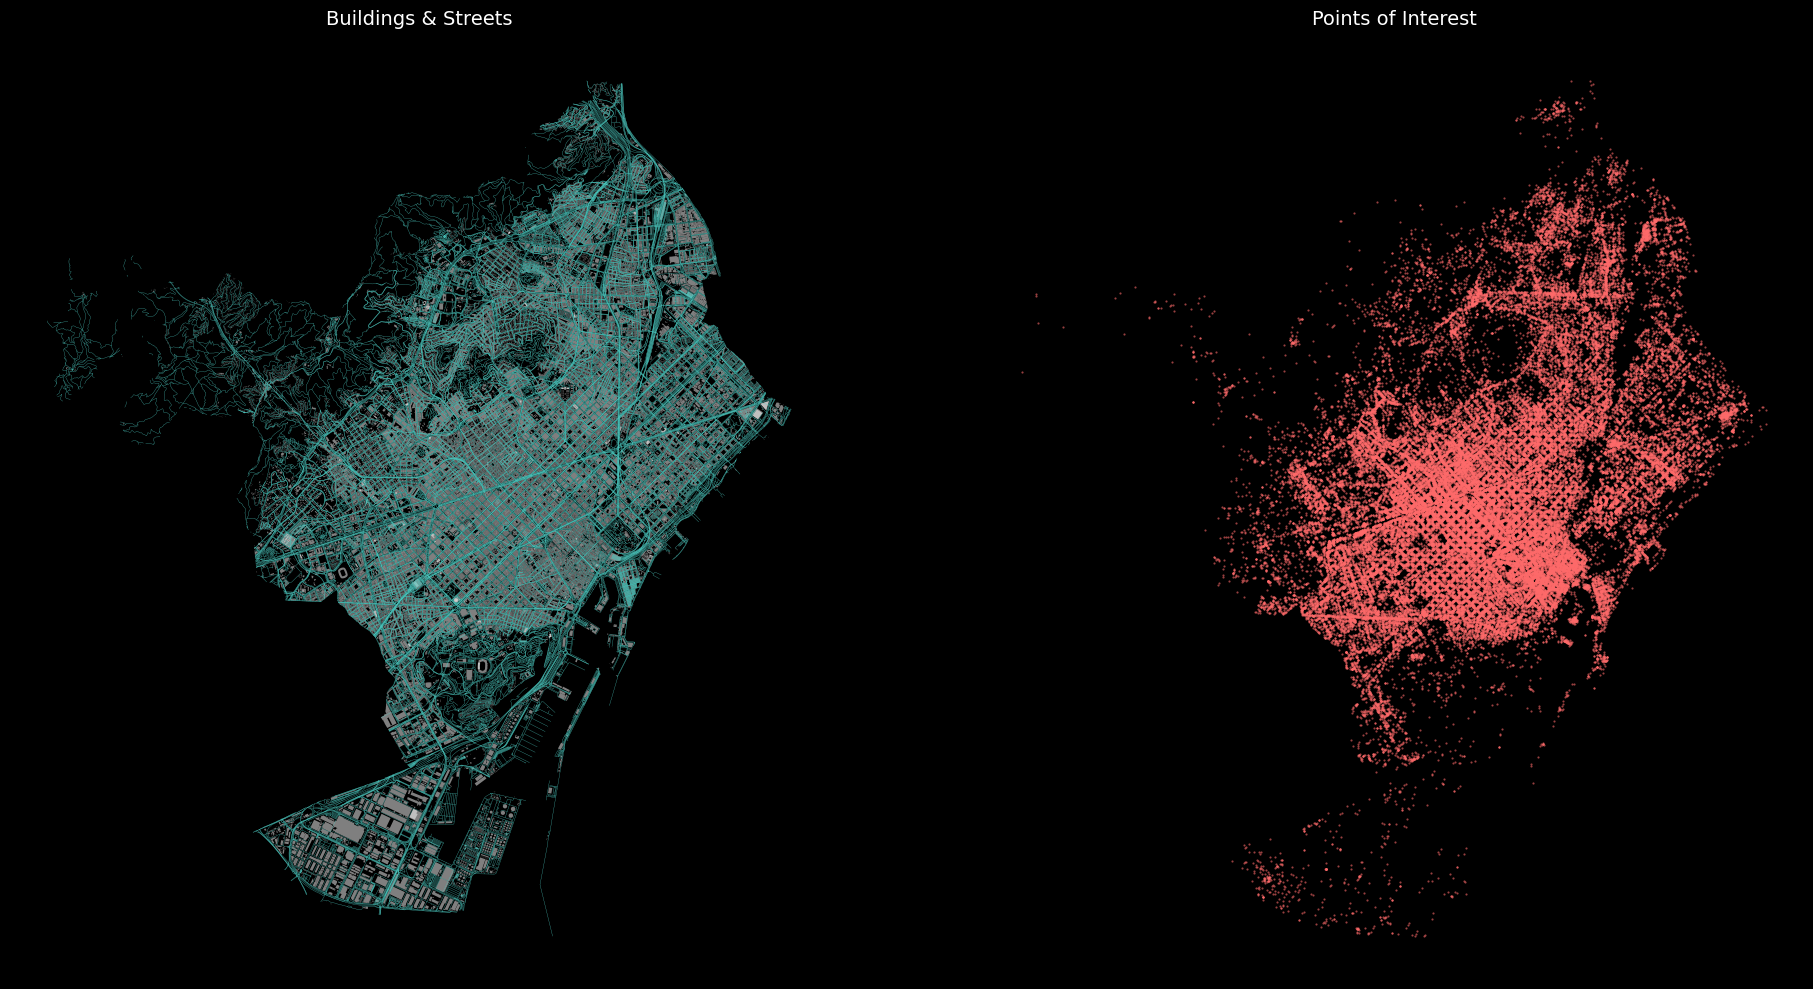

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10), facecolor="#000000")

# Left: buildings and streets
axes[0].set_facecolor("#000000")
buildings.plot(ax=axes[0], color="white", alpha=0.5, linewidth=0.05)
segments.plot(ax=axes[0], color="#4ECDC4", linewidth=0.2)
axes[0].set_axis_off()
axes[0].set_title("Buildings & Streets", color="white", fontsize=14, pad=10)

# Right: POIs
axes[1].set_facecolor("#000000")
places.plot(ax=axes[1], color="#FF6B6B", markersize=0.3, alpha=0.6)
axes[1].set_axis_off()
axes[1].set_title("Points of Interest", color="white", fontsize=14, pad=10)

plt.tight_layout()
plt.show()

Two panels, one function call. The left panel shows Liverpool's street fabric and building footprints; the right reveals the spatial distribution of POIs across the city.

You can fetch any combination of Overture data types by adjusting the `types` parameter:

In [9]:
# Get everything available for Shibuya
data = c2g.load_overture_data(
    place_name="Shibuya, Tokyo",
    types=["building", "segment", "connector", "place", "land_use", "water"],
    save_to_file=False
)

# Project all data to a local metric CRS (UTM)
crs = next(iter(data.values())).estimate_utm_crs()
data = {k: v.to_crs(crs) for k, v in data.items()}


For reproducibility, pin a specific Overture release version with the `release` parameter:

In [10]:
data = c2g.load_overture_data(
    place_name="Barcelona, Spain",
    types=["building", "segment"],
    release="2026-02-18.0",
    save_to_file=False
)

# Project all data to a local metric CRS (UTM)
crs = next(iter(data.values())).estimate_utm_crs()
data = {k: v.to_crs(crs) for k, v in data.items()}


This ensures that your analysis can be replicated exactly, even as Overture continues to publish new data releases.

# Processing Overture segments with `process_overture_segments()`

Raw Overture segments are not quite ready for network analysis out of the box. Unlike OSMnx, which delivers pre-processed street graphs with proper topology, Overture's `segment` features are long linestrings that span entire roads. To build a usable graph, these need to be **split at connector points** — the intersections and junctions that define network topology.

That is what `process_overture_segments()` does:

In [11]:
# Load segments and connectors
data = c2g.load_overture_data(
    place_name="Liverpool, UK",
    types=["segment", "connector"],
    save_to_file=False
)

# Project all data to a local metric CRS (UTM)
crs = next(iter(data.values())).estimate_utm_crs()
data = {k: v.to_crs(crs) for k, v in data.items()}


# Process: split at connectors, extract barriers, cluster endpoints
data["segment"] = data["segment"][data["segment"]["subtype"] == "road"].copy()
processed_segments = c2g.process_overture_segments(
    data["segment"],
    connectors_gdf=data["connector"],
    get_barriers=True,
    threshold=1.0
)

print(processed_segments.columns.tolist())

['id', 'version', 'sources', 'subtype', 'class', 'names', 'connectors', 'routes', 'subclass_rules', 'access_restrictions', 'level_rules', 'destinations', 'prohibited_transitions', 'rail_flags', 'road_surface', 'road_flags', 'speed_limits', 'width_rules', 'subclass', 'geometry', 'split_from', 'split_to', 'length', 'barrier_geometry']


The function performs three key operations:

1. **Segment splitting** — Each long linestring is cut at every connector position, producing short edge-like segments that form a proper network topology
2. **Barrier extraction** — Level rules (e.g., bridges and tunnels) are parsed to generate passable geometries, useful for routing-aware analysis
3. **Endpoint clustering** — Nearby endpoints are snapped together within a configurable `threshold` distance, cleaning up small geometric inconsistencies

The output is a GeoDataFrame with `split_from` and `split_to` columns that map directly to node IDs — ready to be fed into city2graph's graph-building functions like `morphological_graph()` or `gdf_to_nx()`.

Now let us see the difference processing makes. We will build a morphological graph and visualise it with `plot_graph()`:

In [12]:
# Load all needed layers
data = c2g.load_overture_data(
    place_name="Liverpool, UK",
    types=["building", "segment", "connector"],
    save_to_file=False
)

# Project all data to a local metric CRS (UTM)
crs = next(iter(data.values())).estimate_utm_crs()
data = {k: v.to_crs(crs) for k, v in data.items()}

In [13]:
data["segment"] = data["segment"][data["segment"]["subtype"] == "road"].copy()
processed = c2g.process_overture_segments(
    data["segment"],
    get_barriers=True,
    connectors_gdf=data["connector"]
)

In [14]:
from shapely import Point
import geopandas as gpd
center = gpd.GeoSeries([Point(-2.9784, 53.4084)], crs="epsg:4326").to_crs(processed.crs)

In [19]:
data["building"]

,id,version,sources,level,subtype,class,height,names,has_parts,is_underground,...,facade_material,min_floor,num_floors_underground,roof_material,roof_shape,roof_direction,roof_orientation,roof_color,roof_height,geometry
101682,18b68e1e-3a1e-4b11-b40f-e86eeff4655e,2,"[{'property': '', 'dataset': 'OpenStreetMap', ...",NaN,NaN,NaN,5.612975,NaN,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((502247.121 5914150.385, 502240.665 5..."
101683,d7389407-4bb2-49f3-87b1-801135322af2,2,"[{'property': '', 'dataset': 'OpenStreetMap', ...",NaN,NaN,NaN,5.356468,NaN,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((502258.38 5914157.732, 502250.767 59..."
101406,e417315b-999c-45ce-a49d-782845fe80e3,2,"[{'property': '', 'dataset': 'OpenStreetMap', ...",NaN,NaN,NaN,6.466956,NaN,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((502226.901 5914170.433, 502219.926 5..."
101407,112a570e-1ff7-4eac-8fcd-1fc96bc1c975,1,"[{'property': '', 'dataset': 'OpenStreetMap', ...",NaN,NaN,NaN,NaN,NaN,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((502233.643 5914178.902, 502228.024 5..."
101400,55771b6f-0341-4322-932d-aa5ae4bb16c9,2,"[{'property': '', 'dataset': 'OpenStreetMap', ...",NaN,NaN,NaN,4.373584,NaN,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((502210.484 5914182.374, 502202.648 5..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19785,263602a3-4ad6-44a7-85ff-5ae8d6f4b89b,3,"[{'property': '', 'dataset': 'Microsoft ML Bui...",NaN,NaN,NaN,NaN,NaN,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((506401.804 5923910.308, 506396.577 5..."
19783,d2da2f99-3b2b-45dd-93eb-ac388934dd1a,3,"[{'property': '', 'dataset': 'Microsoft ML Bui...",NaN,NaN,NaN,NaN,NaN,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((506402.496 5923923.838, 506400.361 5..."
18760,9e17a49a-7f65-4c7f-8c79-b2e8fce53f6d,2,"[{'property': '', 'dataset': 'OpenStreetMap', ...",NaN,NaN,NaN,6.635830,NaN,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((506405.84 5924165.59, 506422.546 592..."
18720,99634949-88b7-4e1e-b369-76c46060d38f,2,"[{'property': '', 'dataset': 'OpenStreetMap', ...",NaN,industrial,industrial,7.741041,NaN,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((506432.585 5924386.158, 506374.528 5..."


In [15]:
morph_nodes, morph_edges = c2g.morphological_graph(
    buildings_gdf=data["building"],
    segments_gdf=processed,
    center_point=center,
    distance=500,                    # Analysis radius in meters,
    clipping_buffer=300,
    primary_barrier_col="barrier_geometry",
    contiguity="queen",             # Adjacency rule for tessellation
    keep_buildings=True,            # Preserve building geometries
    keep_segments=True,             # Preserve street segment geometries
)

Removed 13 invalid geometries
/Users/yutasato/Projects/Liverpool/city2graph-workshop/.venv/lib/python3.13/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
 There is 1 island with id: 49_77119.
  W.__init__(self, neighbors, ids=ids, **kw)


<Axes: >

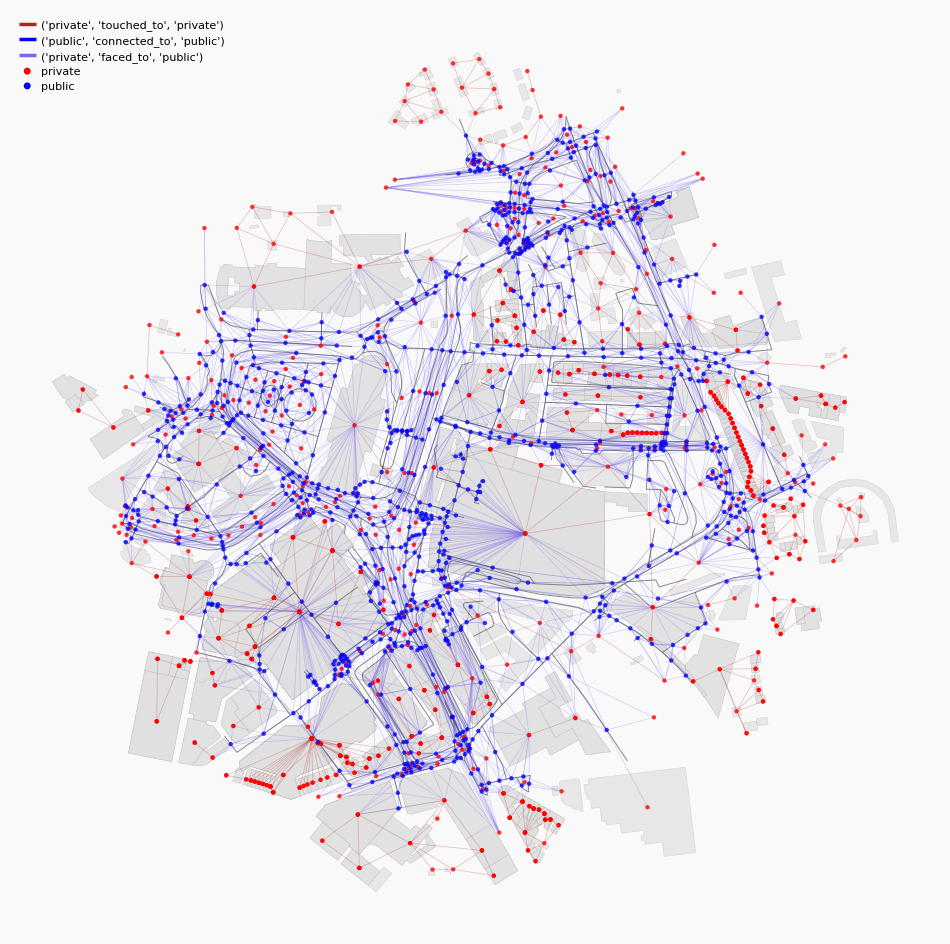

In [16]:
fig, ax = plt.subplots(figsize=(14, 12), facecolor='#f9f9f9')

morph_nodes["private"]["building_geometry"].plot(ax=ax, color='#e0e0e0', edgecolor='#c0c0c0', linewidth=0.3, alpha=0.7)
morph_nodes["public"]["segment_geometry"].plot(ax=ax, color='#404040', linewidth=0.7, alpha=0.6)

c2g.plot_graph(
    nodes=morph_nodes,
    edges=morph_edges,
    subplots=False,
    ax=ax,
    bgcolor="#f9f9f9",
    labelcolor="#000000",
    node_color={'private': 'red', 'public': 'blue'},
    edge_color={
        ('private', 'touched_to', 'private'): '#B22222',
        ('public', 'connected_to', 'public'): '#0000FF',
        ('private', 'faced_to', 'public'): '#7B68EE',
    },
    markersize=10,
    linewidth=0.2,
)


This pipeline — `load_overture_data()` → `process_overture_segments()` → graph construction → `plot_graph()` — is the Overture equivalent of calling `ox.graph_from_place()`. A few functions instead of one, but covering far more data types and producing richer graph structures.

The black background with white edges produces a striking visual that immediately reveals the street pattern and building fabric of the neighbourhood. You can customise colours, line widths, marker sizes, and more:

# Conclusion

city2graph's `load_overture_data()` brings OSMnx-level convenience to the entire Overture Maps catalogue. One function, three input modes — bounding box, polygon, or place name — pick whichever suits your workflow.

Combined with `process_overture_segments()` for topology-ready street networks and `plot_graph()` for beautiful visualisations, you can go from zero to urban graph analysis in minutes. No manual downloads, no format wrangling, no coordinate lookups. Just Python.

- **GitHub**: https://github.com/c2g-dev/city2graph
- **Docs**: https://city2graph.net
- **Previous post**: [city2graph: A Python package for spatial network analysis and GNNs](https://medium.com/@yuta.sato.now/city2graph-a-python-package-for-spatial-network-analysis-and-graph-neural-networks-gnns-bc943dd6d85e)

**Please do not forget to put stars ⭐️ on the GitHub repo!**